In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
np.random.seed(123)
torch.manual_seed(200)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(200)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
torch.cuda.empty_cache()

In [3]:
#### Test 2 ####
## Define the potential function V(x, y) and plot the potential landscape
def potential(x, y):
    return (
        3 * np.exp(-x**2 - (y - 1/3)**2)
        - 3 * np.exp(-x**2 - (y - 5/3)**2)
        - 5 * np.exp(-(x - 1)**2 - y**2)
        - 5 * np.exp(-(x + 1)**2 - y**2)
        + 0.2 * x**4
        + 0.2 * (y - 1/3)**4
    )

# Define the gradient of the potential function
def gradient(x, y):
    dVdx = (
        -6 * x * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * x * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * (x - 1) * np.exp(-(x - 1)**2 - y**2)
        + 10 * (x + 1) * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * x**3
    )
    dVdy = (
        -6 * (y - 1/3) * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * (y - 5/3) * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * y * np.exp(-(x - 1)**2 - y**2)
        + 10 * y * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * (y - 1/3)**3
    )
    return dVdx, dVdy

## Generate m^2 trajectories in the landscape
# Set the parameters for the SDE
#h = 1e-3  # Integration step size
h = 1e-3  # Integration step size
#h = 1e-5  # Integration step size
n_steps = 500  # Number of integration steps between each evaluation
n_eval = 10  # Number of evaluations
lag_time = h * n_steps  # Lag time

# Set the number of points to select in each dimension
m = 35

# Set the diffusion coefficient
sigma = 1.09
print ('Lag time: ', lag_time)



# Generate linspace for x and y coordinates
x_values = np.linspace(-2, 2, m)
y_values = np.linspace(-1, 2, m)

# Create a meshgrid from these linspace arrays
xx, yy = np.meshgrid(x_values, y_values)

# Flatten the meshgrid matrices to get the coordinate pairs
x0_values = xx.flatten()
y0_values = yy.flatten()

# Initialize the data_matrix
data_matrix = np.zeros((m**2, n_eval+1, 2))

# Generate trajectories for each selected point
for i in tqdm (range(m**2)):
    x = x0_values[i]
    y = y0_values[i]
    
    for j in range(n_eval+1):
        data_matrix[i, j, 0] = x
        data_matrix[i, j, 1] = y
        
        for k in range(n_steps):
            dVdx, dVdy = gradient(x, y)
            x += -dVdx * h + sigma * np.sqrt(h) * np.random.normal()
            y += -dVdy * h + sigma * np.sqrt(h) * np.random.normal()

# Create a grid of points
x_plot = np.linspace(-2, 2, 100)
y_plot = np.linspace(-1, 2, 100)
X, Y = np.meshgrid(x_plot, y_plot)



# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)


Lag time:  0.5


  0%|          | 0/1225 [00:00<?, ?it/s]

  0%|          | 2/1225 [00:00<01:21, 15.01it/s]

  0%|          | 4/1225 [00:00<01:21, 14.93it/s]

  0%|          | 6/1225 [00:00<01:20, 15.15it/s]

...

100%|█████████▉| 1220/1225 [01:19<00:00, 15.39it/s]

100%|█████████▉| 1222/1225 [01:20<00:00, 15.42it/s]

100%|█████████▉| 1224/1225 [01:20<00:00, 15.38it/s]

100%|██████████| 1225/1225 [01:20<00:00, 15.27it/s]

Shape of data_X: (1225, 10, 2)
Shape of data_Y: (1225, 10, 2)
Shape of X: (12250, 2)
Shape of Y: (12250, 2)
(8575, 2)


In [4]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_e.torch'

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=100,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K
    }


Outer Epoch 1/100


Epoch: 1 	Training Loss: 0.025067 val loss: 0.032127
saving, val loss enhanced: 0.03212732601540086 1000000000000000.0
Epoch: 2 	Training Loss: 0.025034 val loss: 0.032072
saving, val loss enhanced: 0.03207192362477313 0.03212732601540086


Epoch: 3 	Training Loss: 0.025000 val loss: 0.032037
saving, val loss enhanced: 0.03203650231601539 0.03207192362477313
Outer Epoch 2/100
Epoch: 1 	Training Loss: 0.024968 val loss: 0.031987
saving, val loss enhanced: 0.03198697607323053 0.03203650231601539


Epoch: 2 	Training Loss: 0.024938 val loss: 0.031943
saving, val loss enhanced: 0.03194289033342888 0.03198697607323053
Epoch: 3 	Training Loss: 0.024904 val loss: 0.031902
saving, val loss enhanced: 0.031902061780067346 0.03194289033342888
Outer Epoch 3/100


Epoch: 1 	Training Loss: 0.024868 val loss: 0.031877
saving, val loss enhanced: 0.031876602541992 0.031902061780067346
Epoch: 2 	Training Loss: 0.024837 val loss: 0.031821
saving, val loss enhanced: 0.031820609516442167 0.031876602541992


...

Epoch: 3 	Training Loss: 0.021515 val loss: 0.027566
Outer Epoch 98/100
Epoch: 1 	Training Loss: 0.021513 val loss: 0.027562
saving, val loss enhanced: 0.027562089210518264 0.027564314536352014


Epoch: 2 	Training Loss: 0.021509 val loss: 0.027555
saving, val loss enhanced: 0.027555215459889315 0.027562089210518264
Epoch: 3 	Training Loss: 0.021507 val loss: 0.027545
saving, val loss enhanced: 0.027545378560609537 0.027555215459889315
Outer Epoch 99/100


Epoch: 1 	Training Loss: 0.021504 val loss: 0.027560
Epoch: 2 	Training Loss: 0.021501 val loss: 0.027542
saving, val loss enhanced: 0.027542095899897187 0.027545378560609537


Epoch: 3 	Training Loss: 0.021499 val loss: 0.027534
saving, val loss enhanced: 0.02753355678302036 0.027542095899897187
Outer Epoch 100/100
Epoch: 1 	Training Loss: 0.021491 val loss: 0.027536


Epoch: 2 	Training Loss: 0.021492 val loss: 0.027529
saving, val loss enhanced: 0.02752899868870236 0.02753355678302036
Epoch: 3 	Training Loss: 0.021484 val loss: 0.027527
saving, val loss enhanced: 0.027527360753147444 0.02752899868870236


(15,)
[1.0000+0.0000j 0.9554+0.0000j 0.6346+0.0000j 0.0633+0.0000j
 0.0469+0.0000j 0.0106+0.0000j 0.0041+0.0000j 0.0000+0.0000j
 -0.0000+0.0000j -0.0000-0.0000j -0.0000+0.0000j -0.0003+0.0000j
 -0.0005+0.0000j -0.0028-0.0041j -0.0028+0.0041j]


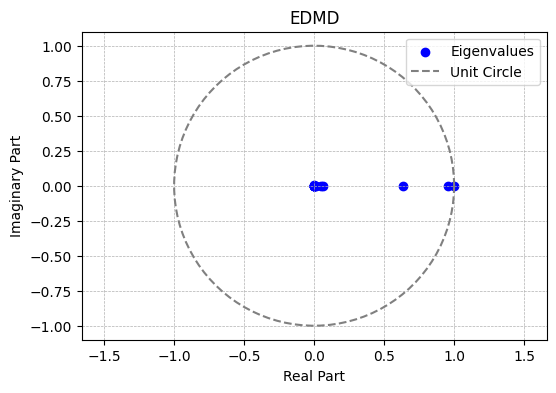

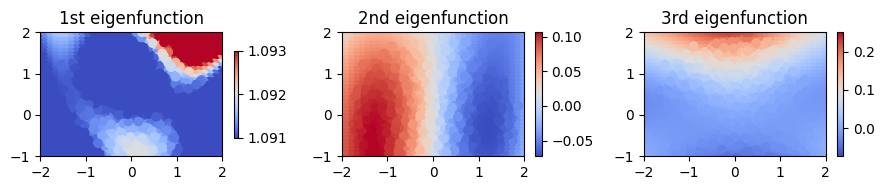

In [5]:
# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
evalues_display = np.real_if_close(evalues, tol=1000)
print(np.array2string(evalues_display, formatter={'float_kind': lambda x: f'{x:.4f}', 'complex_kind': lambda z: f'{z.real:.4f}{z.imag:+.4f}j'}))

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('EDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_s.torch'

np.random.seed(200)
torch.manual_seed(200)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(200)

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)


solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 16, fnn_batch_size= 32, delta_t= lag_time)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=100,
    batch_size=256,
    lr=5e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

# Results from solver_edmd/solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver.get_Psi_X()
Psi_Y = solver.get_Psi_Y()
Koopman_matrix_K = solver.K

outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }


Epoch: 1 	Training Loss: 0.307557 	Validation Loss: 0.209912
Saving model, validation loss improved: 0.209912 < 10000.000000


Epoch: 2 	Training Loss: 0.233345 	Validation Loss: 0.207501
Saving model, validation loss improved: 0.207501 < 0.209912


Epoch: 3 	Training Loss: 0.231310 	Validation Loss: 0.205322
Saving model, validation loss improved: 0.205322 < 0.207501


Epoch: 4 	Training Loss: 0.229419 	Validation Loss: 0.203750
Saving model, validation loss improved: 0.203750 < 0.205322


Epoch: 5 	Training Loss: 0.227776 	Validation Loss: 0.202525
Saving model, validation loss improved: 0.202525 < 0.203750


...

Processing batches:  51%|█████     | 68/134 [00:00<00:00, 218.90batch/s]

Processing batches:  67%|██████▋   | 90/134 [00:00<00:00, 218.17batch/s]

Processing batches:  84%|████████▍ | 113/134 [00:00<00:00, 220.15batch/s]

Processing batches: 100%|██████████| 134/134 [00:00<00:00, 219.49batch/s]

Epoch: 1 	Training Loss: 0.021715 val loss: 0.027876
Epoch: 2 	Training Loss: 0.021660 val loss: 0.027874
EarlyStopping counter: 1 out of 7
Epoch 100 time: 1.01 seconds


(15,)
[1.0000+0.0000j 0.9585+0.0000j 0.6458+0.0000j 0.0889+0.0000j
 0.0515+0.0000j 0.0146-0.0011j 0.0146+0.0011j 0.0000+0.0000j
 -0.0000+0.0000j -0.0000+0.0000j -0.0001+0.0000j -0.0018-0.0003j
 -0.0018+0.0003j -0.0032-0.0101j -0.0032+0.0101j]


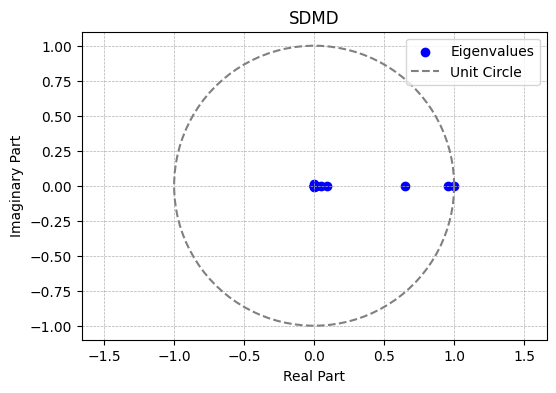

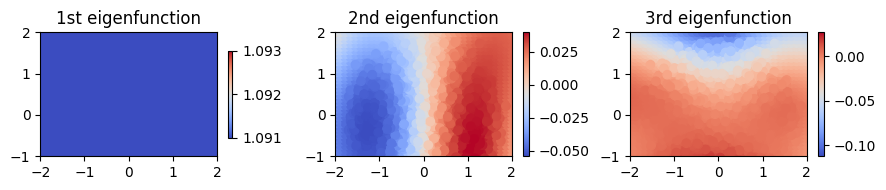

In [7]:
# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
evalues_display = np.real_if_close(evalues, tol=1000)
print(np.array2string(evalues_display, formatter={'float_kind': lambda x: f'{x:.4f}', 'complex_kind': lambda z: f'{z.real:.4f}{z.imag:+.4f}j'}))

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
del solver, basis_function
torch.cuda.empty_cache()

In [9]:
from solver_gedmd_torch_gpu import KoopmanNNTorch as KoopmanNNTorch_g
from solver_gedmd_torch_gpu import KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
checkpoint_file_g= 'well2d_example_ckpt001_g.torch'

basis_function_g = KoopmanNNTorch_g(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)


solver_g = KoopmanSolverTorch_g(dic=basis_function_g, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file_g, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 16, fnn_batch_size= 32)

solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=100,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

# Results from solver_gedmd
evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()


outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }


Epoch: 1 	Training Loss: 0.317274 	Validation Loss: 0.218925
Saving model, validation loss improved: 0.218925 < 10000.000000


Epoch: 2 	Training Loss: 0.231060 	Validation Loss: 0.216423
Saving model, validation loss improved: 0.216423 < 0.218925


Epoch: 3 	Training Loss: 0.229629 	Validation Loss: 0.213934
Saving model, validation loss improved: 0.213934 < 0.216423


Epoch: 4 	Training Loss: 0.227603 	Validation Loss: 0.213237
Saving model, validation loss improved: 0.213237 < 0.213934


Epoch: 5 	Training Loss: 0.226072 	Validation Loss: 0.211685
Saving model, validation loss improved: 0.211685 < 0.213237


...

Processing batches:  75%|███████▍  | 100/134 [00:00<00:00, 157.04batch/s]

Processing batches:  87%|████████▋ | 116/134 [00:00<00:00, 155.64batch/s]

Processing batches:  99%|█████████▊| 132/134 [00:00<00:00, 156.18batch/s]

Processing batches: 100%|██████████| 134/134 [00:00<00:00, 157.52batch/s]

Epoch 100/100, gEDMD loss: 1.801125e-01
Saving best model at epoch 100


(15,)
[1.0000+0.0000j 0.9997+0.0000j 0.9988+0.0000j 0.9977+0.0000j
 0.9942+0.0000j 0.9284+0.0000j 0.5604-0.0540j 0.5604+0.0540j
 0.2594+0.0000j 0.1518+0.0000j 0.0825+0.0000j 0.0217-0.0033j
 0.0217+0.0033j 0.0090+0.0000j 0.0008+0.0000j]


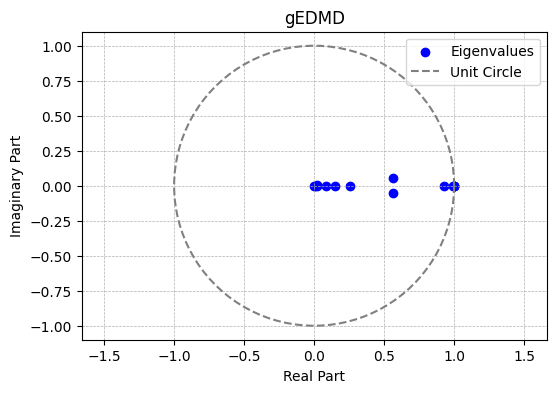

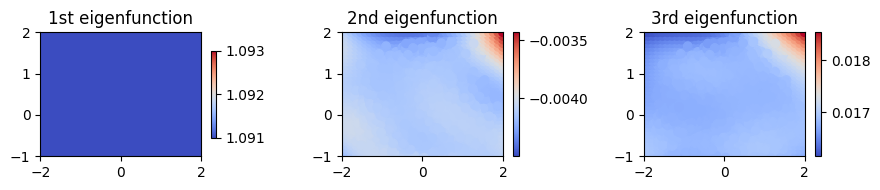

In [10]:
# computing eigenvalues of K from generator eigenvalues using exponetnt
# eigenfunctions are the same for the operator and the generator
evalues_K = np.exp(evalues * lag_time)
sort_idx = evalues_K.real.argsort()[::-1]
evalues_K = evalues_K[sort_idx]
efuns_plot = efuns[:, sort_idx]

# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data
# Assuming evalues is a numpy array of complex numbers

print(evalues_K.shape)
evalues_K_display = np.real_if_close(evalues_K, tol=1000)
print(np.array2string(evalues_K_display, formatter={'float_kind': lambda x: f'{x:.4f}', 'complex_kind': lambda z: f'{z.real:.4f}{z.imag:+.4f}j'}))

# Plot eigenvalues on unit circle
real_parts = evalues_K.real
imag_parts = evalues_K.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right')
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_plot)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_plot)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns_plot)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns_plot)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns_plot)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' gEDMD ', fontsize=16)
plt.tight_layout()
plt.show()
